# Transfer Learning y Fine-Tuning

This notebook has the objective of highlighting the relevance of transfer learning and fine-tuning on pre-trained models to make their usefulness more notable. Particularily, it is a good strategy to make use of pre-trained models to save space and take advantage of already-trained weights to yield better results.

In [45]:
import json
import time
from io import BytesIO
from urllib.request import Request, urlopen

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm

import csv
import os
from PIL import Image
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms

from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

First, let's check for a CUDA environment to make sure we can use GPU (or not) 

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.cuda.is_available()

False

## Dataset

Then, we can construct our dataset. 

The dataset we made consists of:
- 30 images of class `bobby` (dog)
- 30 images of class `horchata` (cat)
- 30 images of class `empanada` (dog)
- 120 images of the control class `not_any`

For this, we can make our own dataset class that reads the CSV file with the labels. The CSV file has a `filename` and `class_idx` for each image, which we can convert to one entry in our dataset.

Items (images) are then constructed with `Image.open` and assumed to have 3 channels (RGB). Transformations are then applied

In [47]:
class FoodDataset(Dataset):
    def __init__(self, csv_path, images_dir, transform=None):
        self.images_dir = images_dir
        self.transform = transform
        with open(csv_path) as f:
            reader = csv.DictReader(f)
            self.samples = [(row["filename"], int(row["class_idx"])) for row in reader]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        fname, label = self.samples[idx]
        img = Image.open(os.path.join(self.images_dir, fname)).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, label

The transformations used are the following:
- Resize to `224x224` pixels
- Convert `PILImage` to `Tensor`s
- Normalize the channel values to constrain them given the restrictions.

In [48]:
transform = transforms.Compose([
      transforms.Resize((224, 224)),
      transforms.ToTensor(),
      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
  ])

Once the transformations and our dataset model are in place, we can instantiate it with our metadata CSV, the image directory and the transformation (preprocessing) pipeline we created.

In [49]:
dataset = FoodDataset("data/labels.csv", "data/images", transform=transform)

Given the populated dataset instance, it has to be partitioned into `train`, `test` and `validation`. For this, we loop through the labels of all images and map them to their index so we have a relation `label -> idx`. This is useful so we can identify each image by its label in the stratification process.

We stratify the partitions because the size of this dataset is considerably smaller than an average-sized set, which means it is likely for categories to be heavily skewed and distributed improperly, and it's much more likely this causes a negative impact in our results. 

Once the dataset is partitioned in `80-10-10`, we load all the subsets.

In [50]:
labels = [sample[1] for sample in dataset.samples]
indices = list(range(len(dataset)))

# train / test split
train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=[labels[i] for i in indices], random_state=42
)

# val test
val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=[labels[i] for i in temp_idx], random_state=42
)

train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)
test_set = Subset(dataset, test_idx)

Put them in a `DataLoader` to make them usable and shuffle `train` for better results.

In [51]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader = DataLoader(test_set,  batch_size=32, shuffle=False)

We can see that the partition was made successfully. Out of 210 images:
- 168 are for train (80%)
- 21 are for validation (10%)
- 21 are for test (10%)

In [52]:
print(f"Train: {len(train_set)} | Val: {len(val_set)} | Test: {len(test_set)}")
print(f"Classes: {{'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}}")

Train: 168 | Val: 21 | Test: 21
Classes: {'bobby': 0, 'empanada': 1, 'horchata': 2, 'not_any': 3}


In [53]:
num_classes = 4

## Pre-trained Models

For the model comparison, we will use two pre-trained models that will undergo a pipeline of transfer learning and fine tuning. For this, we create our own metric evaluation (accuracy) and training function.

Both of these functions can be referenced in our older notebooks.

`get_batch_accuracy` calculates the average accuracy of batches.

In [54]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

`train` iterates over the dataset `epoch` times, partitioning it in batches for every iteration.

In [55]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs, _transforms=None):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }

    for epoch in range(_num_epochs):
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            _x = X_batch
            if _transforms is not None:
                _x = _transforms(_x)
            outputs = _model(_x)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        print(f"Epoch {epoch+1}/{_num_epochs} — "
              f"train_loss: {epoch_train_loss:.4f}  train_acc: {train_acc:.4f}  "
              f"val_loss: {epoch_val_loss:.4f}  val_acc: {val_acc:.4f}")

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

`plot_learning_curves` plots the loss and accuracy metrics of train against validation for contrast.

In [56]:
def plot_learning_curves(res, title):
    epochs = range(1, len(res['train_loss']) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, res['train_loss'], label='Train')
    ax1.plot(epochs, res['val_loss'],   label='Validation')
    ax1.set_title(f'{title} - Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()

    ax2.plot(epochs, res['train_acc'], label='Train')
    ax2.plot(epochs, res['val_acc'],   label='Validation')
    ax2.set_title(f'{title} - Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

### ResNet50

Our first model is **ResNet50**. It is an ImageNet-based model with (presumably) better performance than the baseline.

We can import it directly from `torchvision`.

In [57]:
from torchvision.models import resnet50
from torchvision.models import ResNet50_Weights

Its weights come bundled and contain the trainable parameters of the model.

In [58]:
weights = ResNet50_Weights.DEFAULT
model1 = resnet50(weights=weights)

model1.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

#### Transfer Learning

To apply transfer learning, we must first freeze all the parameters of the model.

In [59]:
# 2. Freeze all parameters
for param in model1.parameters():
    param.requires_grad = False

So we can then replace the classifier head (last layer) with our own. This is so the output can be constrained to our new classes (`bobby`, `horchata`, `empanada`, `not_any`).

In [60]:
# 3. Replace the final classifier (ResNet uses model.fc, not model.classifier)
model1.fc = nn.Linear(model1.fc.in_features, num_classes)

And finally train it using an optimizer (`Adam`) and a loss criterion (`CrossEntropyLoss`, multi-class) appropriate for the problem.

In [61]:
optimizer = torch.optim.Adam(model1.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

In [62]:
res = train(model1, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.2188  train_acc: 0.4821  val_loss: 1.0824  val_acc: 0.5714
Epoch 2/5 — train_loss: 0.8766  train_acc: 0.5893  val_loss: 0.8362  val_acc: 0.6190
Epoch 3/5 — train_loss: 0.6425  train_acc: 0.7798  val_loss: 0.6390  val_acc: 0.9048
Epoch 4/5 — train_loss: 0.4841  train_acc: 0.9464  val_loss: 0.5240  val_acc: 0.9524
Epoch 5/5 — train_loss: 0.3821  train_acc: 0.9702  val_loss: 0.4376  val_acc: 0.9524


Finally, we save the model before doing anything else so it can be retrieved later.

In [63]:
res_resnet_tl = res
torch.save(model1.state_dict(), 'resnet50_tl.pth')

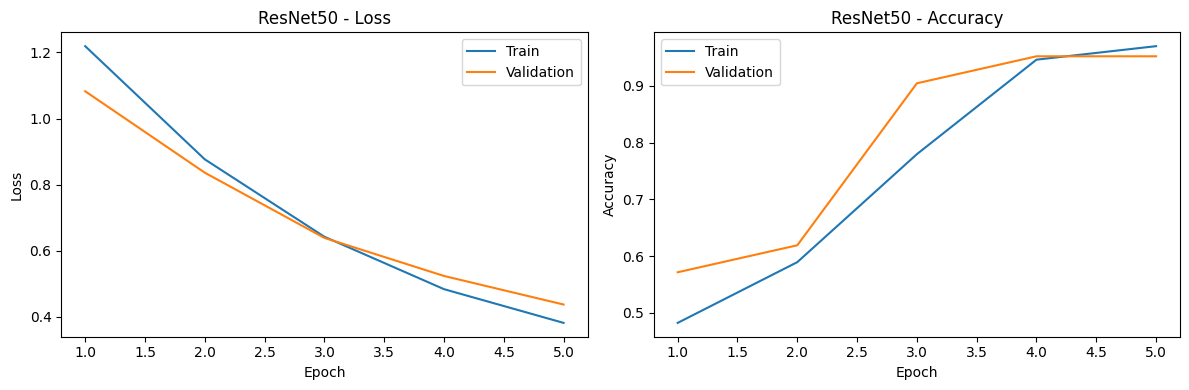

In [64]:
plot_learning_curves(res, title="ResNet50")

As can be seen above, the preliminary results show that accuracy increased progressively until reaching `100%` for validation. This adds up with the results of the loss graph. In a future section we explain the contrast, significance and meaning of this, while comparing it to the second model we evaluate.

#### Fine Tuning

Furthermore, we can fine-tune the model to get even better results. We have "re-trained" it using transfer learning to adapt it to our needs, but we can now selectively train particular layers to get even better prediction metrics.

Once again, first, we can freeze every parameter (of all layers) before we retrain the model. This is because we don't want to modify them at all and lose the "pre" in "pre-trained".

Following that, we can enable the layers that we *do* want to train which, in our case, is the very last layer and the fourth layer. We can iterate over their parameters and unfreeze them.

In [65]:
# all
for param in model1.parameters():
    param.requires_grad = False

# layer 4
for param in model1.layer4.parameters():
    param.requires_grad = True

# last layer
for param in model1.fc.parameters():
    param.requires_grad = True


To visualize how many parameters, we can add up all of the ones that aren't frozen. This is important to understand how training time differs to an untrained model.

In [66]:
trainable = sum(p.numel() for p in model1.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model1.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

Trainable params: 14,972,932 / 23,516,228


Once again, we define the optimizer but, in this case, it defines learning rates for the additional layers we trained. They can be distinct and should be, as the pre-trained layer can advance slower than the layer we inserted (as it needs to be trained from scratch).

In [67]:
ft_optimizer = torch.optim.Adam([
    {"params": model1.layer4.parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model1.fc.parameters(),  "lr": 1e-3}, # New head: normal LR
])
ft_num_epochs = 5

In [68]:
res_ft = train(model1, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.2904  train_acc: 0.9881  val_loss: 0.2965  val_acc: 1.0000
Epoch 2/5 — train_loss: 0.1755  train_acc: 0.9940  val_loss: 0.2126  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.1195  train_acc: 0.9940  val_loss: 0.1605  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.0684  train_acc: 1.0000  val_loss: 0.1249  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.0457  train_acc: 1.0000  val_loss: 0.1057  val_acc: 1.0000


Finally, we save the model again for future use.

In [69]:
res_resnet_ft = res_ft
torch.save(model1.state_dict(), 'resnet50_ft.pth')

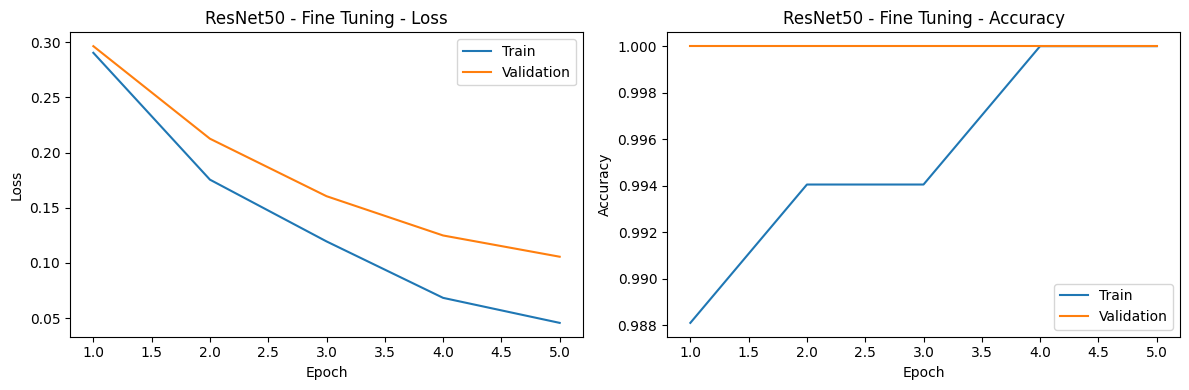

In [70]:
plot_learning_curves(res_ft, title="ResNet50 - Fine Tuning")

### EfficientNet

Next, we will implement EfficientNet-B0 to compare its performance against the previous ResNet50 baseline.

In [71]:
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights


weights = EfficientNet_B0_Weights.DEFAULT
model2 = efficientnet_b0(weights=weights)    

model2.to(device)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

#### Transfer Learning

We first freeze all parameters in the model to preserve the pre-trained features and knowledge from the original model.

In [72]:
for param in model2.parameters():
    param.requires_grad = False

Next, we replace the final layer of the EfficientNet-B0 classifier head. By using the `[-1]` index, we specifically target the last linear layer of the sequence, allowing us to swap the original output for a new `nn.Linear` layer that matches the number of classes in our specific dataset.

In [73]:
model2.classifier[-1] = nn.Linear(model2.classifier[-1].in_features, num_classes)

We also define the optimizer and the loss function. We will use the same hyperparameters as the ResNet50 model.

In [74]:
optimizer = torch.optim.Adam(model2.classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()
num_epochs = 5

Finally, we train the model and visualize the resulting learning curves for EfficientNet-B0. At this point, we are observing the performance of the model using only the Transfer Learning approach, with the feature extractions layers frozen.

In [75]:
res = train(model2, train_loader, val_loader, criterion, optimizer, num_epochs)

Epoch 1/5 — train_loss: 1.2620  train_acc: 0.4524  val_loss: 1.0971  val_acc: 0.6667
Epoch 2/5 — train_loss: 0.9702  train_acc: 0.5952  val_loss: 0.9665  val_acc: 0.6190
Epoch 3/5 — train_loss: 0.8229  train_acc: 0.6845  val_loss: 0.7897  val_acc: 0.6667
Epoch 4/5 — train_loss: 0.6397  train_acc: 0.8393  val_loss: 0.6539  val_acc: 0.8571
Epoch 5/5 — train_loss: 0.5305  train_acc: 0.9226  val_loss: 0.5687  val_acc: 0.8571


In [76]:
#save results before overwrite, or evaluation can fail
res_eff_tl = res
torch.save(model2.state_dict(), 'effnet_tl.pth')

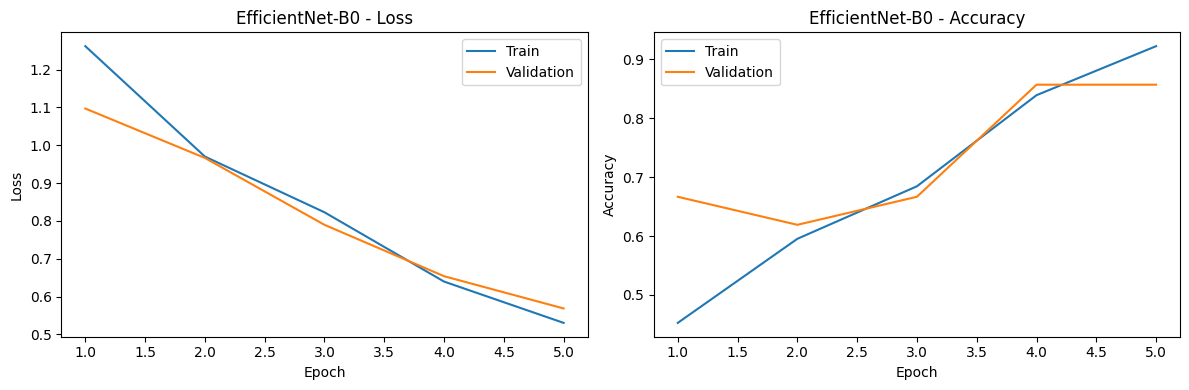

In [77]:
plot_learning_curves(res, title="EfficientNet-B0")

#### Fine Tuning

We will now apply an Advanced Fine-Tuning strategy by following these steps:

* Freeze all parameters to reset the gradient state.
* Unfreeze the final blocks: Based on the EfficientNet-B0 architecture, which organizes its extractor into a features sequence of 9 blocks (0 to 8), we unfreeze from `features[7:]`. This specifically targets the final `MBConv` block and the last `conv-norm` stage, allowing the model to adapt its most complex feature representations to our dataset.
* Unfreeze the classifier head to continue optimizing our specific output layer.

In [78]:
for param in model2.parameters():
    param.requires_grad = False

# Unfreeze the last few layers of the feature extractor 
for param in model2.features[7:].parameters():
    param.requires_grad = True

# Unfreeze the classifier head
for param in model2.classifier.parameters():
    param.requires_grad = True

A lower learning rate is assigned to the pre-trained feature extractor, while a standard learning rate is kept for the classifier head.

In [79]:
ft_optimizer = torch.optim.Adam([
    {"params": model2.features[7:].parameters(), "lr": 1e-5}, # Pre-trained: low LR
    {"params": model2.classifier.parameters(), "lr": 1e-3}, # New head: normal LR   
])

In [80]:
ft_num_epochs = 5

With the Fine-Tuning process complete, we have optimized the last blocks of the EfficientNet-B0 architecture for our specific pet dataset. (Add some insights PENDING)

In [81]:
res_ft = train(model2, train_loader, val_loader, criterion, ft_optimizer, ft_num_epochs)

Epoch 1/5 — train_loss: 0.4342  train_acc: 0.9464  val_loss: 0.4882  val_acc: 0.9048
Epoch 2/5 — train_loss: 0.3386  train_acc: 0.9702  val_loss: 0.4170  val_acc: 1.0000
Epoch 3/5 — train_loss: 0.2503  train_acc: 0.9821  val_loss: 0.3611  val_acc: 1.0000
Epoch 4/5 — train_loss: 0.2231  train_acc: 0.9821  val_loss: 0.3184  val_acc: 1.0000
Epoch 5/5 — train_loss: 0.1746  train_acc: 0.9940  val_loss: 0.2877  val_acc: 1.0000


In [82]:
#save results before overwrite, or evaluation can fail
res_eff_ft = res_ft
torch.save(model2.state_dict(), 'effnet_ft.pth')

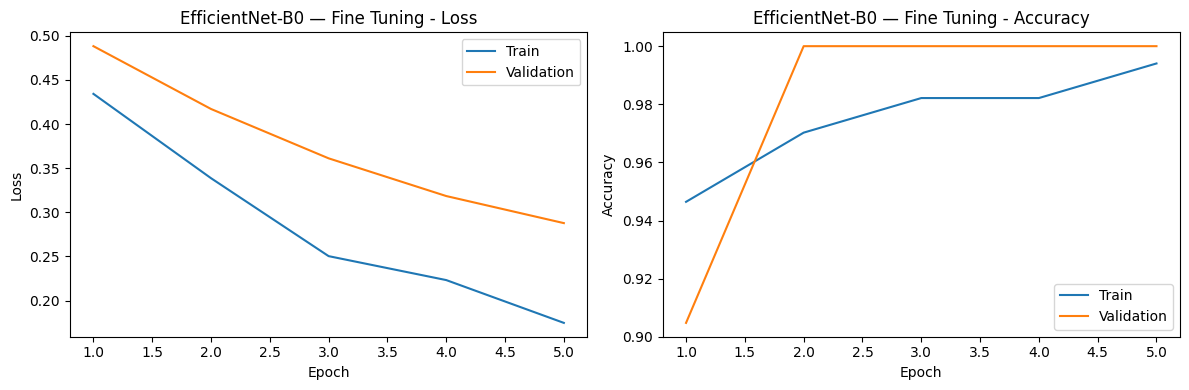

In [83]:
plot_learning_curves(res_ft, title="EfficientNet-B0 — Fine Tuning")

## Evaluation and Comparison

The validation loss and accuracy curves for all four configurations are plotted to see how they change during training and to help identify which one performs best.

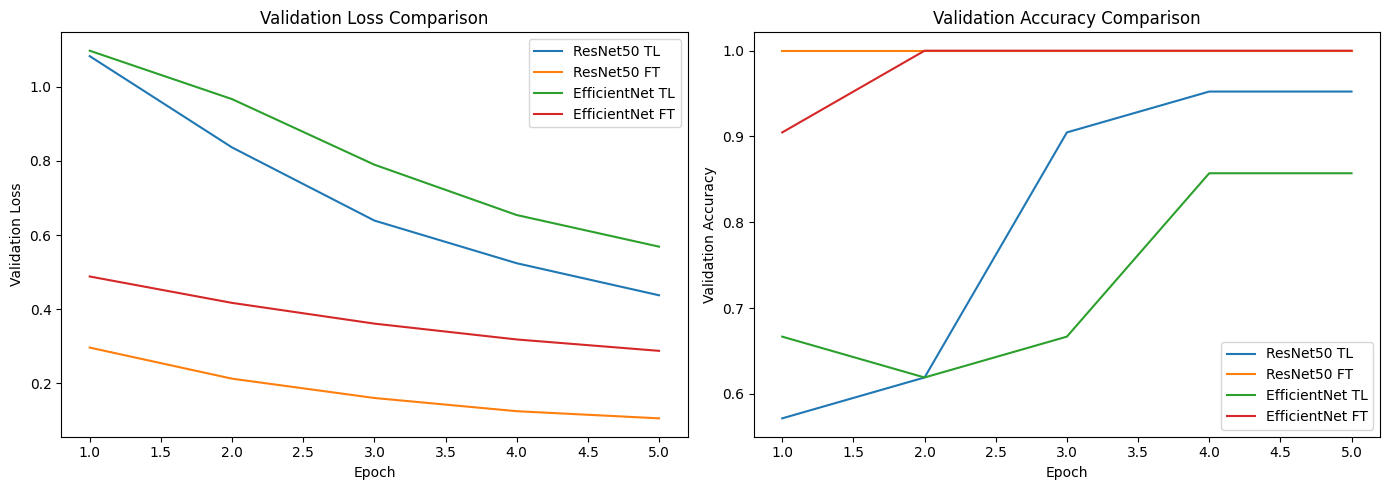

In [84]:
all_results = {
    'ResNet50 TL': res_resnet_tl,
    'ResNet50 FT': res_resnet_ft,
    'EfficientNet TL': res_eff_tl,
    'EfficientNet FT': res_eff_ft,
}

fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for name, r in all_results.items():
    ep = range(1, len(r['val_loss']) + 1)
    axs[0].plot(ep, r['val_loss'], label=name)
    axs[1].plot(ep, r['val_acc'],  label=name)

axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Validation Loss')
axs[0].set_title('Validation Loss Comparison')
axs[0].legend()

axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Validation Accuracy')
axs[1].set_title('Validation Accuracy Comparison')
axs[1].legend()

plt.tight_layout()
plt.show()

Looking at the validation loss curves,the models with fine-tuning drop faster and reach lower values than the transfer learning ones, which makes sense since more parameters are being adjusted to the dataset. On the accuracy side, EfficientNet with fine-tuning already performs well from the start,while both transfer learning models begin much lower and take more time to improve.ResNet50 with transfer learning manages to reach very high accuracy after a few epochs, while EfficientNet with transfer learning stays at a lower level,showing a clear difference between them 

### Model Comparison

The final validation accuracy and loss for all four configurations are compared to select the best model for test evaluation.

In [85]:
print(f"{'Model':<25} {'Val Loss':>10} {'Val Acc':>10}")
print('-' * 47)

best_name = None
best_acc = -1

for name, r in all_results.items():
    final_loss = r['val_loss'][-1]
    final_acc  = r['val_acc'][-1]
    print(f"{name:<25} {final_loss:>10.4f} {final_acc:>10.4f}")
    if final_acc > best_acc:
        best_acc = final_acc
        best_name = name

print(f"\nBest model: {best_name} with {best_acc:.4f} validation accuracy")

Model                       Val Loss    Val Acc
-----------------------------------------------
ResNet50 TL                   0.4376     0.9524
ResNet50 FT                   0.1057     1.0000
EfficientNet TL               0.5687     0.8571
EfficientNet FT               0.2877     1.0000

Best model: ResNet50 FT with 1.0000 validation accuracy


As can be seen from the final validation results, ResNet50 with fine-tuning reaches a validation accuracy of 1.0 in the last epochs and also achieves the lowest validation loss. In general, the models with fine-tuning perform better than those using transfer learning. By allowing the last convolutional layers to update with a low learning rate,the model can better adjust its more complex features to fit the patterns in this dataset, something that doesnt happen when all layers are kept fixed. Because of this, ResNet50 Fine-Tunning is chosen as the best model for the final test evaluation.

## Best Model Evaluation on Test Set

Based on the final validation accuracy, the best model is selected and evaluated once on the test set. 

In [86]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

checkpoint_map = {
    'ResNet50 TL': (model1, 'resnet50_tl.pth'),
    'ResNet50 FT': (model1, 'resnet50_ft.pth'),
    'EfficientNet TL': (model2, 'effnet_tl.pth'),
    'EfficientNet FT': (model2, 'effnet_ft.pth'),
}

best_model_arch, best_ckpt = checkpoint_map[best_name]
best_model_arch.load_state_dict(torch.load(best_ckpt, map_location=device))
best_model_arch.to(device)
best_model_arch.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = best_model_arch(X_batch)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = np.mean(all_preds == all_labels)
print(f'Best model: {best_name}')
print(f'Test accuracy: {test_acc:.4f}')

Best model: ResNet50 FT
Test accuracy: 1.0000


ResNet50 with fine-tuning achieved the best test accuracy. The fact that the test result is very close to the validation accuracy shows that the model generalizes well. This gives a reliable idea of how the model would perform on a new data

### Classification Report

With the best model selected, a classification report is generated on the test set 
including precision, recall, and F1-score.

In [87]:
class_names = ['bobby', 'empanada', 'horchata', 'not_any']

print(classification_report(all_labels, all_preds, target_names=class_names, labels=range(len(class_names))))

              precision    recall  f1-score   support

       bobby       1.00      1.00      1.00         3
    empanada       1.00      1.00      1.00         3
    horchata       1.00      1.00      1.00         3
     not_any       1.00      1.00      1.00        12

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21



Looking at the results, the model performs consistently across all classes.Precision and recall are high for every categorys. The overall accuracy also matches what we saw on the test set,which shows the resultsare consistent. Its also important note that the score 1.00 are expected given the small size of the test set. With only a few samples class and clear visual differences between them, pretrained models can classify them without much difficulty.

### Confusion Matrix

The confusion matrix gives a more detailed view of where the model makes mistakes, 
showing which classes get confused with each other.

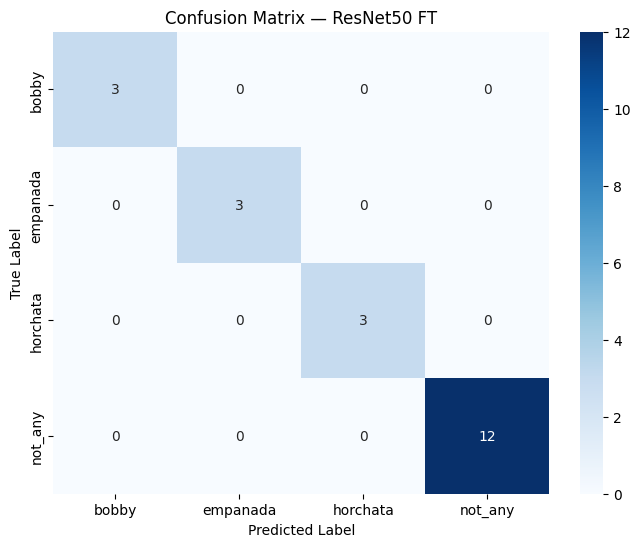

In [88]:
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Confusion Matrix — {best_name}')
plt.show()

The confusion matrix is diagonal, with no values outside it,which means every test sample was classified correctly.This matches the accuracy and F1 scores shown in the classification report. As mentioned earlier, this result makes sense considering the small test set and the clear visual differences between the classes.

## Personal Reflection

In conclusion, this activity made it clear that transfer learning is a great starting point, but fine-tuning gives better results. Letting the last layers adjust to the dataset improves both accuracy and loss, especially with a small dataset like this. Overall, pretrained models make the process much faster and more effective.